In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
tracks = pd.read_csv("C:\\Users\\minne\\Documents\\School\\Jaar 3\\Blok 1\\Sciptie\\Python\\Data\\LFM-2b\\tracks.tsv", sep='\t', on_bad_lines='skip')

In [3]:
tracks = tracks[tracks["artist_name"].notna()]

In [4]:
tracks = tracks[~tracks["artist_name"].isin(["<Unknown>", "[unknown]", "Various Artists"])]

In [5]:
tracks

,track_id,artist_name,track_name
0,0,Mika Miko,NaN
1,1,Comm,
2,2,deadmau5,
3,3,Rasheed Chappell,
4,4,rck,
...,...,...,...
50723391,50813368,ЗупиниЛося,"🦌 ЗупиниЛося №60. Бійки, стрілянина і табуни д..."
50723392,50813369,ЗупиниЛося,🦌 ЗупиниЛося №69. Повний паркувальний бардак н...
50723393,50813370,Lost Cascades,🧝‍♀️ 𝒜 𝒮𝓉𝓇𝒶𝓃𝑔𝑒𝓇 𝒜𝓅𝓅𝓇𝑜𝒶𝒸𝒽𝑒𝓈: '𝒟𝓇𝒶𝓊⻕
50723394,50813371,Lost Cascades,🧝♀️ 𝒜 𝒮𝓉𝓇𝒶𝓃𝑔𝑒𝓇 𝒜𝓅𝓅𝓇𝑜𝒶𝒸𝒽𝑒𝓈: '𝒟𝓇𝒶𝓊𝑔𝒽𝓉 𝑜𝒻 𝐵𝓁𝑒𝓈𝓈𝑒𝒹...


In [3]:
users = pd.read_csv("C:\\Users\\minne\\Documents\\School\\Jaar 3\\Blok 1\\Sciptie\\Python\\Data\\LFM-2b\\users.tsv", sep='\t')

In [4]:
users

,user_id,country,age,gender,creation_time
0,0,UK,31,m,2002-12-28 01:00:00
1,1,US,43,m,2003-04-15 02:00:00
2,2,UK,35,m,2002-10-29 01:00:00
3,3,BR,31,m,2003-07-20 02:00:00
4,4,NaN,51,m,2003-07-21 02:00:00
...,...,...,...,...,...
120317,120317,RU,19,m,2012-07-21 18:15:05
120318,120318,NaN,-1,n,2012-07-23 21:17:42
120319,120319,BY,19,f,2012-07-19 22:07:27
120320,120320,NaN,-1,m,2012-07-23 19:25:08


In [8]:
artists = tracks["artist_name"].unique()

In [9]:
with open('trackArtist.pkl', 'rb') as f:
    trackArtist = pickle.load(f)

with open('artistTrack.pkl', 'rb') as f:
    artistTrack = pickle.load(f)

In [16]:
with open('codesCountry.pkl', 'rb') as f:
    codesCountry = pickle.load(f)

In [5]:
countrycount = users.groupby('country').count()["user_id"].sort_values(ascending=False)
countrycount[:50]

country
US    10255
RU     5024
DE     4578
UK     4534
PL     4408
BR     3886
FI     1409
NL     1375
ES     1243
SE     1231
UA     1143
CA     1077
FR     1055
AU      976
IT      974
JP      806
NO      750
MX      705
CZ      632
BY      558
BE      513
ID      484
TR      479
CL      425
HR      372
PT      291
AR      282
CH      277
AT      276
DK      272
HU      272
RS      253
RO      237
BG      236
IE      220
LT      202
SK      192
GR      175
LV      165
NZ      164
CN      162
CO      159
IR      135
IN      122
VE      118
EE      107
IL      100
KZ       90
ZA       84
PE       71
Name: user_id, dtype: int64

In [24]:
countryUsercount = {}
for row in countrycount.keys():
    countryUsercount[codesCountry[row]] = codesCountry[row] + ", " + str(countrycount[row]) + " users"

In [25]:
countryUsercount

{'United States': 'United States, 10255 users',
 'Russian Federation': 'Russian Federation, 5024 users',
 'Germany': 'Germany, 4578 users',
 'United Kingdom': 'United Kingdom, 4534 users',
 'Poland': 'Poland, 4408 users',
 'Brazil': 'Brazil, 3886 users',
 'Finland': 'Finland, 1409 users',
 'Netherlands': 'Netherlands, 1375 users',
 'Spain': 'Spain, 1243 users',
 'Sweden': 'Sweden, 1231 users',
 'Ukraine': 'Ukraine, 1143 users',
 'Canada': 'Canada, 1077 users',
 'France': 'France, 1055 users',
 'Australia': 'Australia, 976 users',
 'Italy': 'Italy, 974 users',
 'Japan': 'Japan, 806 users',
 'Norway': 'Norway, 750 users',
 'Mexico': 'Mexico, 705 users',
 'Czech Republic': 'Czech Republic, 632 users',
 'Belarus': 'Belarus, 558 users',
 'Belgium': 'Belgium, 513 users',
 'Indonesia': 'Indonesia, 484 users',
 'Turkey': 'Turkey, 479 users',
 'Chile': 'Chile, 425 users',
 'Croatia': 'Croatia, 372 users',
 'Portugal': 'Portugal, 291 users',
 'Argentina': 'Argentina, 282 users',
 'Switzerland': 

In [26]:
with open('countryUsercount.pkl', 'wb+') as f:
    pickle.dump(countryUsercount, f)

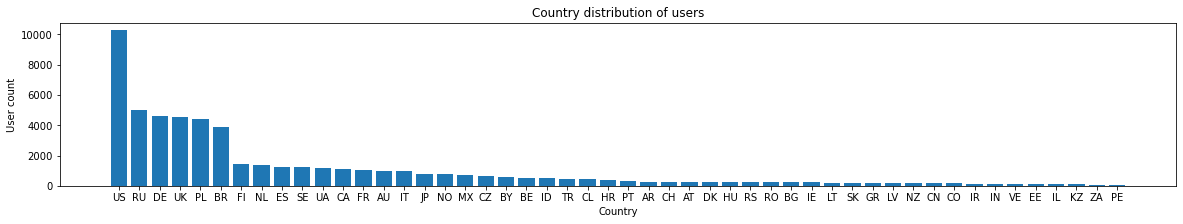

In [11]:
labels = countrycount.keys()[:50]
sizes = countrycount[:50]

plt.rcParams["figure.figsize"] = (20,3)
fig, ax = plt.subplots()
ax.bar(labels, sizes)
ax.set_ylabel('User count')
ax.set_xlabel('Country')
ax.set_title('Country distribution of users')
plt.show()

In [12]:
userage = users.groupby('age').count()["user_id"].sort_index(ascending=True)
userage[:]

age
-1      74202
 0         36
 1         27
 2         28
 3         29
        ...  
 108        9
 109       10
 110        8
 111       33
 112       26
Name: user_id, Length: 114, dtype: int64

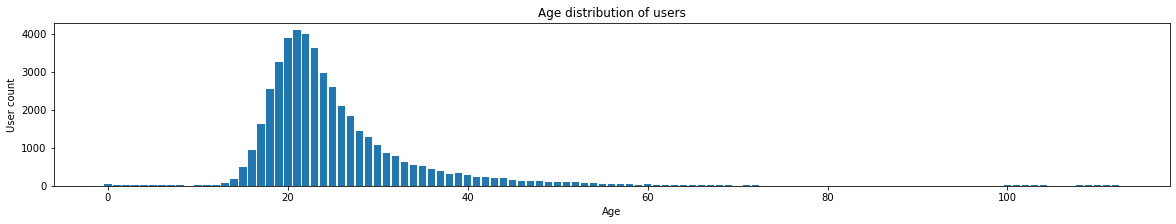

In [13]:
labels = userage.keys()[1:]
sizes = userage[1:]

fig, ax = plt.subplots()
ax.bar(labels, sizes)
plt.rcParams["figure.figsize"] = (20,3)
ax.set_ylabel('User count')
ax.set_xlabel('Age')
ax.set_title('Age distribution of users')
plt.show()

In [14]:
usergender = users.groupby('gender').count()["user_id"].sort_values(ascending=False)
usergender[1:]

gender
m    39969
f    15802
Name: user_id, dtype: int64

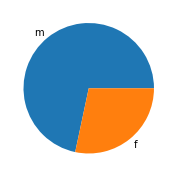

In [15]:
labels = usergender.keys()[1:]
sizes = usergender[1:]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels)
plt.rcParams["figure.figsize"] = (20,3)
plt.show()

In [16]:
artisttrackcount = tracks.groupby('artist_name').count()["track_id"].sort_values(ascending=False)


In [17]:
artisttrackcount[:50]

artist_name
Johann Sebastian Bach       167799
Wolfgang Amadeus Mozart     107045
Ludwig van Beethoven         71740
Antonio Vivaldi              57292
Frédéric Chopin              45836
The Beatles                  42540
Georg Friedrich Händel       37050
Pyotr Ilyich Tchaikovsky     29832
Various Artists              29794
Richard Wagner               27860
Soundtrack                   27814
Armin van Buuren             27122
Franz Joseph Haydn           26954
Pink Floyd                   26531
Franz Schubert               26377
Johannes Brahms              25673
Ennio Morricone              24333
Die drei ???                 24238
Depeche Mode                 23823
Glenn Gould                  23073
John Williams                22179
Bob Dylan                    21518
Metallica                    20626
Giuseppe Verdi               20461
Igor Stravinsky              20245
Elvis Presley                19815
David Bowie                  19528
Claude Debussy               19423
BBC Radi

In [18]:
tracks[tracks["artist_name"] == 'Johann Sebastian Bach']

,track_id,artist_name,track_name
670,1314,Johann Sebastian Bach,!8<D>=8O „ 13
2119,2921,Johann Sebastian Bach,"Ich ruf zu dir, Herr Jesu Christ in F Minor, ..."
4994,5985,Johann Sebastian Bach,"Aber am ersten Tage / No.14 Chor: ""Wo willst d..."
5081,6076,Johann Sebastian Bach,"Ach Gott vom Himmel sieh darein, BWV 741"
5085,6080,Johann Sebastian Bach,"Ach Herr, mich armen Sünder BWV 135"
...,...,...,...
50573537,50663514,Johann Sebastian Bach,马太受难曲（选段） 第一部 神的旨意定要成全
50573538,50663515,Johann Sebastian Bach,马太受难曲（选段） 第一部 请承认我
50573539,50663516,Johann Sebastian Bach,马太受难曲（选段） 第一部 轮唱
50573540,50663517,Johann Sebastian Bach,马太受难曲（选段） 第二部 啊！我的耶稣被带走了
